# Twitter Sentiment Analysis on Apple and Google Products

## Phase 4 Project

*Author:* Keith Njihia

*Business Problem:*
Build a machine learning model that can automatically classify tweets as positive, negative, or neutral.

# Executive Summary

This project develops a Natural Language Processing (NLP) model to 
automatically classify tweets about Apple and Google products as 
positive, negative, neutral, or indeterminate sentiment.

*Business and Data Understanding:*
The dataset contains 9,093 tweets sourced from CrowdFlower via 
data.world, labeled by human raters into four sentiment categories. 
After removing duplicates and missing values, 9,070 tweets remained 
for analysis. The dataset showed significant class imbalance, with 
neutral tweets (5,375) dominating over positive (2,970), negative 
(569), and indeterminate (156) tweets.

*Data Preparation:*
Text preprocessing steps included lowercasing, removal of URLs, 
mentions, punctuation, and special characters, followed by stopword 
removal using NLTK. TF-IDF vectorization with 5,000 features was 
used to convert cleaned text into numerical representations suitable 
for machine learning models.

*Modeling:*
Three classification models were trained and evaluated: Multinomial 
Naive Bayes, Logistic Regression, and Random Forest Classifier. 
An 80/20 train-test split with a fixed random state was used to 
ensure reproducibility.

*Evaluation:*
Logistic Regression achieved the highest overall performance, 
demonstrating the strongest ability to correctly classify sentiment 
across categories. All models struggled with minority classes due 
to class imbalance.

*Conclusion:*
Logistic Regression is recommended as the production model for 
automated sentiment monitoring of social media content related to 
Apple and Google products.

# Business Understanding

Companies receive thousands of social media comments every day. Reading each tweet manually is time-consuming and inefficient.

The goal of this project is to develop a machine learning model capable of automatically identifying whether a tweet expresses positive, negative, or neutral sentiment toward Apple and Google products.

Such a system can help businesses monitor customer satisfaction and respond quickly to public feedback.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin-1')


# Data Understanding

In this section, we explore the structure of the dataset, identify missing values, and understand the available features.

In [2]:
# Preview the first few rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [3]:
# Check shape, columns and data types
print(df.shape)
print(df.columns)
print(df.dtypes)

# Check class distribution of target column
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

(9093, 3)
Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')
tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object


No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

In [4]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(f"Duplicates: {df.duplicated().sum()}")

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64
Duplicates: 22


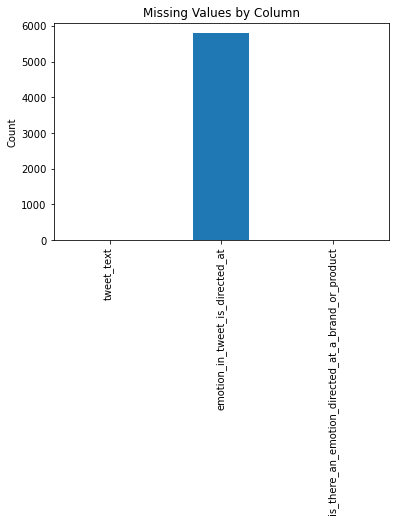

In [5]:
df.isnull().sum().plot(kind='bar')

plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.show()

In [6]:
# Drop duplicates
df = df.drop_duplicates()

# Drop the 1 missing tweet_text row
df = df.dropna(subset=['tweet_text'])

# Drop the column we don't need
df = df.drop(columns=['emotion_in_tweet_is_directed_at'])

# Confirm clean
print(df.shape)
print(df.isnull().sum())

(9070, 2)
tweet_text                                            0
is_there_an_emotion_directed_at_a_brand_or_product    0
dtype: int64


In [7]:
# Rename target column for easier use
df = df.rename(columns={'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'})


# Exploratory Data Analysis

In [8]:
#Sentiment counts
df['sentiment'].value_counts()


No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
I can't tell                           156
Name: sentiment, dtype: int64

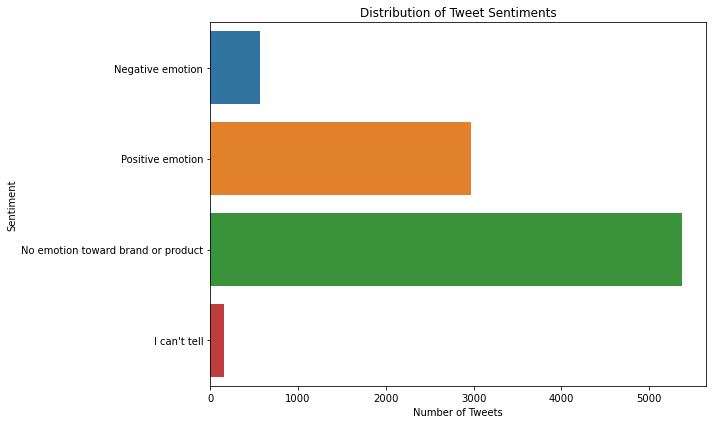

In [9]:
# Ploting the distribution of sentiments
plt.figure(figsize=(10,6))

sns.countplot(
    y='sentiment',
    data=df
)

plt.title('Distribution of Tweet Sentiments')
plt.xlabel('Number of Tweets')
plt.ylabel('Sentiment')

plt.tight_layout()
plt.show()

### Findings

The majority of tweets express no emotion toward a brand or product. Positive tweets are the second most common category, while negative tweets and unclear sentiments represent a much smaller proportion of the dataset. This indicates a class imbalance that should be considered during model development and evaluation.

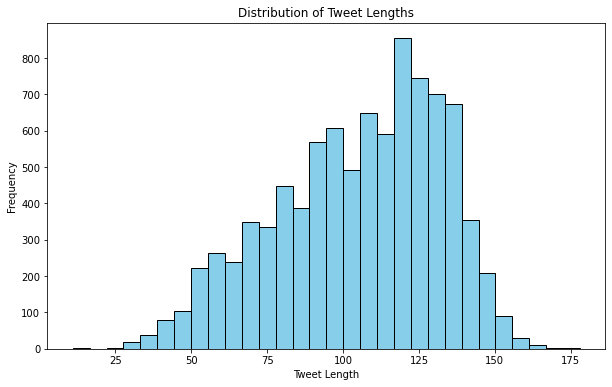

In [10]:
# Tweet length distribution
df['tweet_length'] = df['tweet_text'].str.len()

plt.figure(figsize=(10,6))

plt.hist(df['tweet_length'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')

plt.show()

Most tweets are short in length, which is expected since Twitter limits character usage. This indicates that the model will be working with short text inputs, making TF-IDF and simple classifiers suitable.

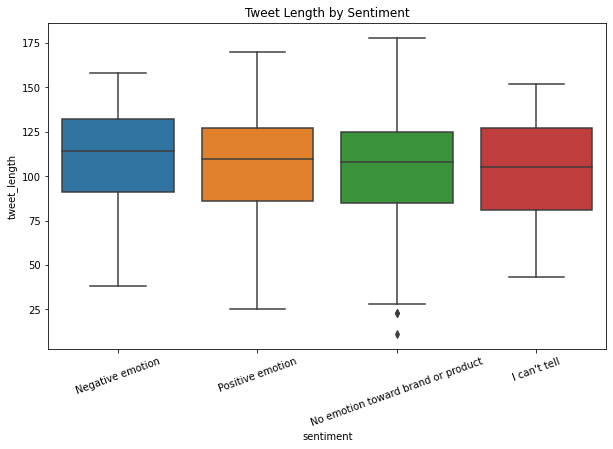

In [11]:
#Tweet length by sentiment
plt.figure(figsize=(10,6))

sns.boxplot(
    x='sentiment',
    y='tweet_length',
    data=df
)

plt.xticks(rotation=20)
plt.title('Tweet Length by Sentiment')

plt.show()

There is slight variation in tweet length across sentiment classes, but no extreme differences. This suggests tweet length alone is not a strong predictor of sentiment.

# Data Preparation

This section prepares the tweet data for machine learning by handling missing values, cleaning text, and transforming the text into a format suitable for modeling.

In [12]:
#checking for missing values again
df.isnull().sum()

tweet_text      0
sentiment       0
tweet_length    0
dtype: int64

The dataset was inspected for missing values. Missing observations in key columns were removed to ensure data quality during model training.

In [13]:
print(df.shape)

(9070, 3)


In [14]:
#Removing missing tweets and Sentiments
df = df.dropna(subset=['tweet_text', 'sentiment'])

In [15]:
print(df.shape)

(9070, 3)


### Handling Missing Values

Missing values were checked in the tweet_text and sentiment columns. No missing observations were found in these key features, so no rows were removed during this step.

In [16]:
#Duplicates
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


The data was checked for duplicates. No duplicates were identified.

## Text Cleaning

The tweet text was cleaned to improve model performance. This included converting text to lowercase, removing URLs, mentions, punctuation, and special characters.

In [17]:
#Text cleaning
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove Twitter mentions
    text = re.sub(r"@\w+", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text


In [18]:
df['clean_tweet'] = df['tweet_text'].apply(clean_text)

In [19]:
df[['tweet_text', 'clean_tweet']].head()

,tweet_text,clean_tweet
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a g iphone after hrs tweeting at rise...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know about awesome ipadiphone app that youl...
2,@swonderlin Can not wait for #iPad 2 also. The...,can not wait for ipad also they should sale ...
3,@sxsw I hope this year's festival isn't as cra...,i hope this years festival isnt as crashy as ...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff on fri sxsw marissa mayer google ...


The cleaning process successfully standardized the text by removing unnecessary characters while preserving meaningful words for sentiment analysis.

## Stopword Removal

Common English stopwords were removed from the cleaned tweets to reduce noise and focus on words that contribute meaningful information to sentiment classification.

In [20]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
stop_words = set(stopwords.words('english'))

In [22]:
def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [23]:
df['clean_tweet'] = df['clean_tweet'].apply(remove_stopwords)

In [24]:
df[['tweet_text', 'clean_tweet']].head()

,tweet_text,clean_tweet
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,g iphone hrs tweeting riseaustin dead need upg...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,hope years festival isnt crashy years iphone a...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri sxsw marissa mayer google tim ...


### Results

Stopwords were successfully removed from the tweet text. This reduces unnecessary noise and allows the model to focus on more informative words when learning sentiment patterns.

## Feature Engineering

In this section, we convert the cleaned tweet text into numerical 
features using TF-IDF (Term Frequency-Inverse Document Frequency). 
TF-IDF assigns higher weights to words that are frequent in a tweet 
but rare across all tweets, making it effective for distinguishing 
sentiment-related words.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the clean tweets
X = tfidf.fit_transform(df['clean_tweet'])

# Target variable
y = df['sentiment']

print(X.shape)
print(y.value_counts())

(9070, 5000)
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
I can't tell                           156
Name: sentiment, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (7256, 5000)
Testing set: (1814, 5000)


## Modeling

We will train and evaluate three models: Naive Bayes, Logistic 
Regression, and Random Forest. We start simple and increase complexity.

## Model 1: Multinomial Naive Bayes

Multinomial Naive Bayes is a popular baseline model for text classification tasks. It is computationally efficient and often performs well on TF-IDF features.

In [27]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Evaluate
nb_pred = nb_model.predict(X_test)
acc1 = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {acc1:.4f}")
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.6781
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        33
                  Negative emotion       0.83      0.04      0.08       119
No emotion toward brand or product       0.69      0.91      0.79      1106
                  Positive emotion       0.63      0.39      0.48       556

                          accuracy                           0.68      1814
                         macro avg       0.54      0.34      0.34      1814
                      weighted avg       0.67      0.68      0.63      1814



c:\Users\Lenovo\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Model Evaluation

The Multinomial Naive Bayes model achieved an accuracy of 67.8% on the test set. The model performed best on the majority class ("No emotion toward brand or product") but struggled with minority classes such as "I can't tell" and "Negative emotion". This suggests that class imbalance may be affecting model performance.

## Model 2: Logistic Regression

Logistic Regression is a widely used classification algorithm that often performs well on TF-IDF text features. It was evaluated and compared against the Naive Bayes baseline.

In [28]:
from sklearn.linear_model import LogisticRegression

# Train model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6929
                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        33
                  Negative emotion       0.77      0.08      0.15       119
No emotion toward brand or product       0.72      0.88      0.79      1106
                  Positive emotion       0.62      0.50      0.55       556

                          accuracy                           0.69      1814
                         macro avg       0.53      0.37      0.37      1814
                      weighted avg       0.68      0.69      0.66      1814



c:\Users\Lenovo\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Model Evaluation

The Logistic Regression model achieved an accuracy of 69.3% on the test dataset, slightly outperforming the Naive Bayes model. The model showed stronger performance in identifying positive emotions and tweets with no emotion toward a brand or product. However, it still struggled to correctly classify minority classes such as "Negative emotion" and "I can't tell", likely due to class imbalance in the dataset.

Overall, Logistic Regression was selected as the better-performing model because it achieved the highest accuracy and more balanced classification performance across the major sentiment categories.

## Model Comparison

The performance of the Naive Bayes and Logistic Regression models was compared using accuracy scores on the test dataset.

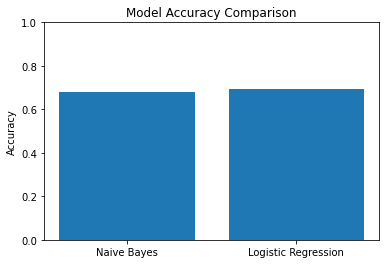

In [29]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression']
accuracies = [0.6781, 0.6929]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

plt.show()

### Model Comparison Results

Logistic Regression achieved the highest accuracy (69.3%), followed by Naive Bayes (67.8%). While both models performed reasonably well, Logistic Regression provided a small but meaningful improvement in overall predictive performance and was chosen as the preferred model for sentiment classification.

## Model 3: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance. It was evaluated to determine whether a more complex model could outperform Naive Bayes and Logistic Regression.

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
rf_pred = rf_model.predict(X_test)

In [33]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6753
                                    precision    recall  f1-score   support

                      I can't tell       0.40      0.06      0.11        33
                  Negative emotion       0.76      0.24      0.36       119
No emotion toward brand or product       0.70      0.87      0.77      1106
                  Positive emotion       0.59      0.43      0.50       556

                          accuracy                           0.68      1814
                         macro avg       0.61      0.40      0.43      1814
                      weighted avg       0.66      0.68      0.65      1814



### Model Evaluation

The Random Forest model achieved an accuracy of 67.5% on the test dataset. While it performed reasonably well on the majority class, it did not outperform Logistic Regression. This suggests that the additional complexity of Random Forest did not provide a significant advantage for this text classification task.

Overall, Logistic Regression remained the best-performing model and was selected as the final model for sentiment prediction.

# Model Interpretability

To better understand how the model makes predictions, the most influential words associated with different sentiment classes were examined. This helps identify which terms contribute most strongly to positive, negative, and neutral sentiment predictions.

In [34]:
feature_names = tfidf.get_feature_names()

for i, class_name in enumerate(lr_model.classes_):
    top_features = lr_model.coef_[i].argsort()[-10:]

    print(f"\nTop words for {class_name}:")
    
    for idx in top_features:
        print(feature_names[idx])


Top words for I can't tell:
home
thinks
fight
juwan
gave
evangelist
bet
might
nuts
circles

Top words for Negative emotion:
another
iphone
hate
deleting
fades
button
long
headaches
sucks
fail

Top words for No emotion toward brand or product:
starting
facebook
happens
codes
pm
mobile
designing
sxsw
amp
link

Top words for Positive emotion:
nice
excited
fun
wow
ipad
smart
love
awesome
great
cool


### Key Findings

The model identified several meaningful words that contributed strongly to sentiment classification. For example, words such as "love", "awesome", "great", and "cool" were strongly associated with positive sentiment. Conversely, words such as "hate", "sucks", "fail", and "headaches" were strongly associated with negative sentiment.

These findings indicate that the model is learning reasonable language patterns and making predictions based on sentiment-bearing words rather than random features.

# Recommendations

Based on the analysis, the following recommendations are proposed:

1. Use Logistic Regression as the primary sentiment classification model due to its superior performance.
2. Monitor customer sentiment toward Apple and Google products to identify emerging trends.
3. Investigate negative sentiment tweets to better understand customer concerns and areas for improvement.
4. Use sentiment analysis as a decision-support tool for marketing and product teams.

# Limitations

Several limitations should be considered:

- The dataset is imbalanced, with the majority of tweets classified as having no emotion toward a brand or product.
- Some sentiment categories contain relatively few observations, making them difficult for the model to learn.
- Tweets are short and may contain slang, abbreviations, or sarcasm that are difficult to interpret accurately.
- The analysis is limited to the available dataset and may not generalize perfectly to future social media content.

# Conclusion

This project developed and evaluated multiple machine learning models to classify tweet sentiment regarding Apple and Google products. After cleaning and preparing the text data, TF-IDF vectorization was used to transform tweets into numerical features. Three classification models were evaluated: Multinomial Naive Bayes, Logistic Regression, and Random Forest.

Among the evaluated models, Logistic Regression achieved the highest accuracy of 69.3%, making it the preferred model for sentiment classification. The results demonstrate that machine learning can effectively identify sentiment patterns in social media text and provide valuable insights for businesses seeking to understand customer opinions.